# 08 — Stage 1 RQ1: Model Comparison

Unified hold-out comparison of the three vision paradigms on the same 2,016–2,018 building test set:
supervised CNN (**ResNet-50** full fine-tune), self-supervised frozen (**DINOv2** ViT-B/14), zero-shot VLM (**InternVL3-2B**).
Metrics: type accuracy, type macro-F1, construction-year MAE, TABULA period accuracy, floor-count MAE.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from _stage1_plot import (REPO, REPORTS_DIR, setup_mpl, save_fig, save_table)
setup_mpl()

# Sources: DINOv2 + ResNet holdout_metrics.json (computed by eval_holdout.py);
# VLM v3 metrics come from its holdout metrics JSON.
SRC = {
    'DINOv2 frozen':  REPORTS_DIR / 'dinov2_frozen' / 'holdout_metrics.json',
    'ResNet-50 ft':   REPORTS_DIR / 'resnet50_ft'   / 'holdout_metrics.json',
    'InternVL3 (ZS)': REPORTS_DIR / 'vlm_internvl3'  / 'v3_holdout_metrics.json',
}
metrics = {k: json.loads(Path(v).read_text()) for k, v in SRC.items() if Path(v).exists()}
print('loaded:', list(metrics.keys()))

loaded: ['DINOv2 frozen', 'ResNet-50 ft', 'InternVL3 (ZS)']


## 1. Headline comparison table

In [2]:
def period_acc(m):
    return m.get('period_acc', m.get('period_accuracy'))
rows = []
for name, m in metrics.items():
    rows.append({
        'model':         name,
        'type_acc':      m.get('type_acc'),
        'type_macro_f1': m.get('type_macro_f1'),
        'year_mae':      m.get('year_mae'),
        'period_acc':    period_acc(m),
        'floors_mae':    m.get('floors_mae'),
    })
comp = pd.DataFrame(rows)
save_table(comp, 'T3_model_comparison')
comp

[tbl] reports\tables\stage1\T3_model_comparison.csv  +  T3_model_comparison.md


,model,type_acc,type_macro_f1,year_mae,period_acc,floors_mae
0,DINOv2 frozen,0.9014,0.5197,9.45,0.9009,0.377
1,ResNet-50 ft,0.9148,0.4919,11.82,0.8915,0.428
2,InternVL3 (ZS),0.4945,0.2458,30.65,0.7688,0.708


## 2. Comparison bar charts

Higher is better for accuracy / macro-F1 / period accuracy; lower is better for the two MAEs (marked ↓).

[fig] reports\figures\stage1\F_model_comparison.png  +  F_model_comparison.pdf


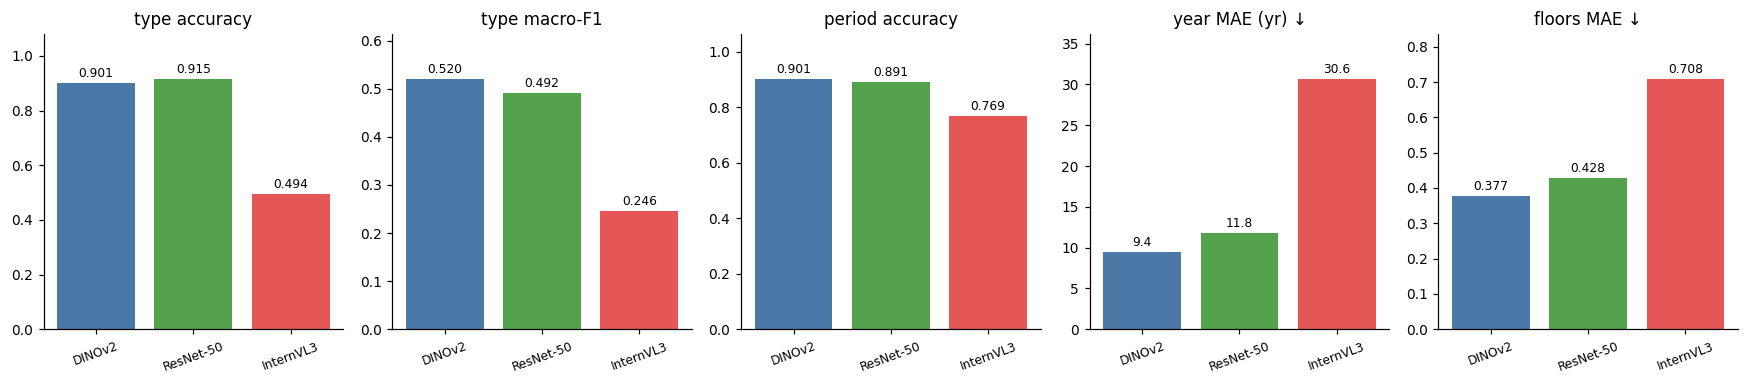

In [3]:
MODEL_PALETTE = {'DINOv2 frozen': '#4C78A8', 'ResNet-50 ft': '#54A24B', 'InternVL3 (ZS)': '#E45756'}
models = list(comp['model'])
colors = [MODEL_PALETTE.get(m, '#888888') for m in models]
panels = [('type_acc', 'type accuracy', False),
          ('type_macro_f1', 'type macro-F1', False),
          ('period_acc', 'period accuracy', False),
          ('year_mae', 'year MAE (yr) ↓', True),
          ('floors_mae', 'floors MAE ↓', True)]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, (col, title, lower_better) in zip(axes, panels):
    vals = comp[col].astype(float).values
    ax.bar(range(len(models)), vals, color=colors)
    ax.set_title(title)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.split()[0] for m in models], rotation=20, fontsize=8)
    top = max(vals) * 1.18 if max(vals) > 0 else 1
    ax.set_ylim(0, top)
    for i, v in enumerate(vals):
        ax.text(i, v + top*0.02, f'{v:.3f}' if v < 5 else f'{v:.1f}', ha='center', fontsize=8)
fig.tight_layout()
save_fig(fig, 'F_model_comparison', '.')
plt.show()

### Reading

- **DINOv2 frozen ≈ ResNet-50 ft** on type (CIs overlap); DINOv2 slightly better on year/period/floors.
- **InternVL3 zero-shot** trails on every attribute but its year/period are usable after the v3 no-anchor prompt fix.
- This is the RQ1 answer: frozen SSL features match full fine-tuning; zero-shot VLM is the deployable-but-weaker option.